# **Model 1**

# Data Loading & Preprocessing

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import kagglehub

path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

data_dir = os.path.join(path, 'EuroSAT')

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=26,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=26,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Classes: {class_names}")

100%|██████████| 2.04G/2.04G [00:17<00:00, 127MB/s] 

Extracting files...


Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Model Architecture

In [2]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(64, 64, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

Training

In [3]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 161s 230ms/step - accuracy: 0.4085 - loss: 1.5428 - val_accuracy: 0.5487 - val_loss: 1.2088
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 136s 201ms/step - accuracy: 0.5380 - loss: 1.2472 - val_accuracy: 0.6594 - val_loss: 0.9837
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 135s 200ms/step - accuracy: 0.6141 - loss: 1.0665 - val_accuracy: 0.7150 - val_loss: 0.7907
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 154s 218ms/step - accuracy: 0.6565 - loss: 0.9615 - val_accuracy: 0.7111 - val_loss: 0.8026
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 136s 202ms/step - accuracy: 0.6914 - loss: 0.8739 - val_accuracy: 0.7289 - val_loss: 0.7510
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 134s 199ms/step - accuracy: 0.7088 - loss: 0.8214 - val_accuracy: 0.7600 - val_loss: 0.6619
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 135s 200ms/step - accuracy: 0.7321 - loss: 0.7656 - val_accuracy: 0.7941 - val_loss: 0.5888
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 136s 201ms/step - accuracy: 0.7485 -

Evaluation & Final Predictions

Evaluating model on validation set...


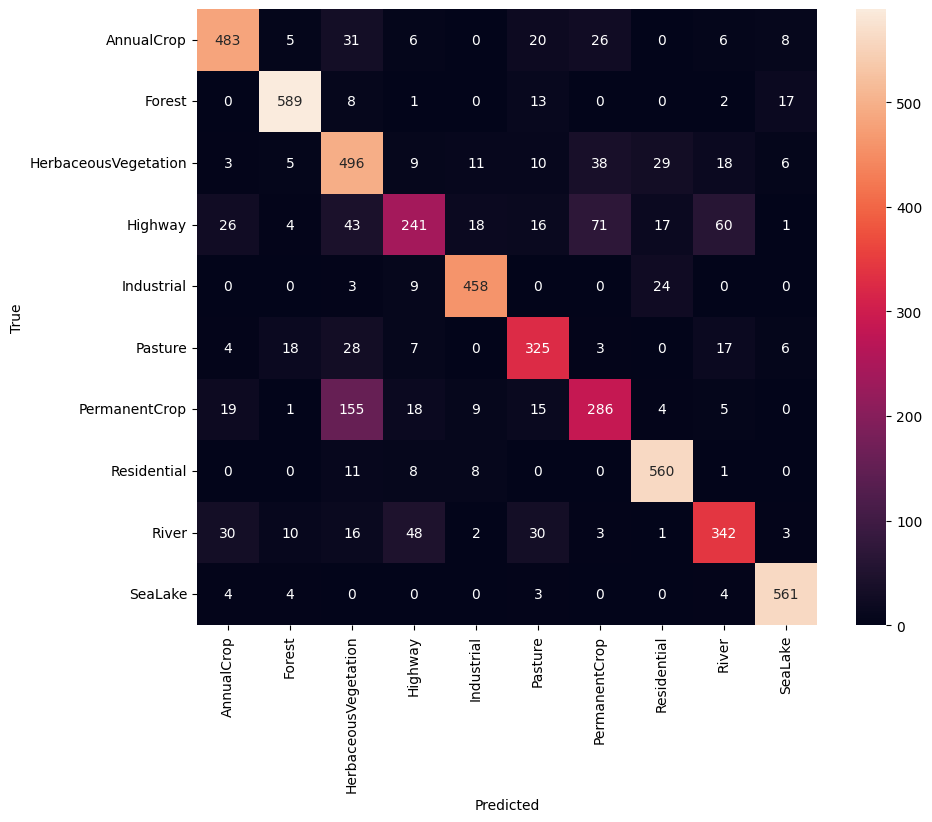

                      precision    recall  f1-score   support

          AnnualCrop       0.85      0.83      0.84       585
              Forest       0.93      0.93      0.93       630
HerbaceousVegetation       0.63      0.79      0.70       625
             Highway       0.69      0.48      0.57       497
          Industrial       0.91      0.93      0.92       494
             Pasture       0.75      0.80      0.77       408
       PermanentCrop       0.67      0.56      0.61       512
         Residential       0.88      0.95      0.92       588
               River       0.75      0.71      0.73       485
             SeaLake       0.93      0.97      0.95       576

            accuracy                           0.80      5400
           macro avg       0.80      0.80      0.79      5400
        weighted avg       0.80      0.80      0.80      5400



In [4]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure val_ds and model exist before running
try:
    # Get labels and predictions for validation set
    y_true = []
    y_pred = []
    print("Evaluating model on validation set...")
    for x, y in val_ds:
        y_true.extend(y.numpy())
        preds = model.predict(x, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names))
except NameError as e:
    print(f"Error: {e}. Run the Data Loading (Step 1) and Training (Step 3) cells first.")